# Notebook 3 — ETL: Limpieza y Transformación

**Proyecto:** Portfolio Data Analyst — E-Commerce Analysis  
**Prerrequisito:** Notebook 2 ejecutada — esta notebook parte de las 9 tablas ya separadas.  
**Entregable:** 9 CSVs limpios + 1 Excel con 9 hojas de datos + 1 hoja de decisiones ETL.

**Objetivo:** Aplicar todas las transformaciones de limpieza en el orden correcto respetando las dependencias entre pasos, documentando cada decisión con su justificación de negocio y su impacto en el análisis posterior.

**Orden de ejecución — las dependencias importan:**
```
1. Separación (viene de NB2) → 2. Tipos → 3. Estandarización texto → 4. Deduplicación
→ 5. Nulos → 6. Outliers → 7. Columnas calculadas → 8. Verificación → 9. Exportación → 10. Log
```

---
## Índice
1. [Setup y carga de tablas desde Notebook 2](#1)
2. [Corrección de tipos de datos](#2)
3. [Estandarización de texto](#3)
4. [Deduplicación](#4)
5. [Tratamiento de nulos](#5)
6. [Tratamiento de outliers](#6)
7. [Columnas calculadas](#7)
8. [Verificación del dataset limpio](#8)
9. [Exportación — CSVs + Excel](#9)
10. [Documentación de decisiones ETL](#10)

---
## 1. Setup y carga de tablas desde Notebook 2 <a id='1'></a>

Esta notebook es la continuación directa de la Notebook 2. No repite la separación en tablas — parte de las 9 tablas ya definidas. La función `tabla_final()` se reimporta aquí para reproducibilidad: si alguien ejecuta solo esta notebook, tiene todo lo necesario para reproducir el resultado desde el dataset crudo.

El primer paso registra el **snapshot inicial** de cada tabla — filas, columnas, nulos y rangos antes de cualquier transformación. Este snapshot es el baseline de comparación en la verificación final.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import os
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

os.makedirs('../data/clean/', exist_ok=True)
os.makedirs('../assets/', exist_ok=True)

DATA_PATH   = '../data/data.csv'
EXCEL_PATH  = '../data/clean/ecommerce_uk_clean.xlsx'
CSV_DIR     = '../data/clean/'

In [2]:
# Se reimporta aquí para garantizar reproducibilidad independiente

def tabla_final(row):
    """
    Asigna cada fila a su tabla definitiva.
    Cascada de dos filtros:
    1°: patrón de StockCode → identifica la fuente
    2°: Quantity + UnitPrice + CustomerID → separa ventas de ajustes de inventario
    """
    sc        = str(row['StockCode']).strip()
    es_cancel = str(row['InvoiceNo']).startswith('C')
    es_ajuste = (
        not es_cancel and
        row['Quantity']  < 0 and
        row['UnitPrice'] == 0 and
        pd.isna(row['CustomerID'])
    )
    # Grupo 1: productos numéricos
    if re.match(r'^\d{5}[A-Za-z]{0,2}$', sc):
        return 'inventory_adjustments' if es_ajuste else 'dim_ventas'
    # Grupo 2: admin
    if sc in ['POST', 'DOT', 'C2']:                  return 'dim_envios'
    if sc in ['M', 'm', 'B']:                        return 'dim_ajustes_contables'
    if sc in ['D', 'CRUK', 'PADS']:                  return 'dim_conceptos_directo'
    if sc in ['S', 'AMAZONFEE']:                     return 'dim_conceptos_indirecto'
    if sc == 'BANK CHARGES':                         return 'dim_conceptos_mixto'
    # Grupo 3: canales externos
    if sc.startswith('DCGS'):                        return 'dim_channel_external'
    if sc.startswith('gift_'):                       return 'dim_voucher'
    return 'sin_clasificar'

df_raw = pd.read_csv(DATA_PATH, encoding='latin1')
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
df_raw['_tabla']      = df_raw.apply(tabla_final, axis=1)

COLS   = ['InvoiceNo','StockCode','Description','Quantity',
          'InvoiceDate','UnitPrice','CustomerID','Country']
TABLAS = ['dim_ventas','inventory_adjustments','dim_envios',
          'dim_ajustes_contables','dim_conceptos_directo',
          'dim_conceptos_indirecto','dim_conceptos_mixto',
          'dim_channel_external','dim_voucher']

# Separar — cada tabla es una copia independiente
tablas = {t: df_raw[df_raw['_tabla']==t][COLS].copy().reset_index(drop=True)
          for t in TABLAS}

print(f'Dataset cargado: {len(df_raw):,} filas originales')
print(f'Sin clasificar:  {(df_raw["_tabla"]=="sin_clasificar").sum()} → OK ✓')
for t, sub in tablas.items():
    print(f'  {t:<35} {len(sub):>8,} filas · {sub["StockCode"].nunique():>5} SC únicos')

Dataset cargado: 541,909 filas originales
Sin clasificar:  0 → OK ✓
  dim_ventas                           537,590 filas ·  3933 SC únicos
  inventory_adjustments                  1,324 filas ·  1070 SC únicos
  dim_envios                             2,110 filas ·     3 SC únicos
  dim_ajustes_contables                    575 filas ·     3 SC únicos
  dim_conceptos_directo                     97 filas ·     3 SC únicos
  dim_conceptos_indirecto                   97 filas ·     2 SC únicos
  dim_conceptos_mixto                       37 filas ·     1 SC únicos
  dim_channel_external                      45 filas ·    16 SC únicos
  dim_voucher                               34 filas ·     5 SC únicos


In [3]:
snapshot_inicial = {}
for nombre, sub in tablas.items():
    snapshot_inicial[nombre] = {
        'filas':        len(sub),
        'sc_unicos':    sub['StockCode'].nunique(),
        'nulos_cid':    sub['CustomerID'].isna().sum(),
        'nulos_desc':   sub['Description'].isna().sum(),
        'dups_exactos': sub.duplicated().sum(),
        'qty_min':      sub['Quantity'].min(),
        'qty_max':      sub['Quantity'].max(),
        'price_min':    sub['UnitPrice'].min(),
        'price_max':    sub['UnitPrice'].max(),
    }

snap_df = pd.DataFrame(snapshot_inicial).T

snap_df

,filas,sc_unicos,nulos_cid,nulos_desc,dups_exactos,qty_min,qty_max,price_min,price_max
dim_ventas,537590.0,3933.0,132681.0,584.0,5262.0,-80995.0,80995.0,0.000,649.50
inventory_adjustments,1324.0,1070.0,1324.0,855.0,0.0,-9600.0,-1.0,0.000,0.00
dim_envios,2110.0,3.0,764.0,6.0,0.0,-4.0,1000.0,0.000,8142.75
dim_ajustes_contables,575.0,3.0,110.0,0.0,5.0,-1350.0,1600.0,-11062.060,38970.00
dim_conceptos_directo,97.0,3.0,0.0,0.0,0.0,-720.0,1.0,0.000,1867.86
dim_conceptos_indirecto,97.0,2.0,97.0,0.0,1.0,-1.0,1.0,1.000,17836.46
dim_conceptos_mixto,37.0,1.0,25.0,0.0,0.0,-1.0,1.0,0.001,1050.15
dim_channel_external,45.0,16.0,45.0,7.0,0.0,-11.0,20.0,0.000,16.63
dim_voucher,34.0,5.0,34.0,2.0,0.0,1.0,30.0,0.000,42.55


**Punto de partida del ETL registrado.** Todas las transformaciones siguientes se compararán contra este baseline en el paso 8.

---
## 2. Corrección de tipos de datos <a id='2'></a>

La corrección de tipos es la **primera transformación** del pipeline porque todas las demás dependen de ella. Si `CustomerID` sigue siendo `float64` al deduplicar o hacer joins, los resultados son incorrectos o impredecibles.

**Transformaciones necesarias:**
- `CustomerID` float64 → Int64 (entero nullable de pandas — soporta NA sin convertir a float)
- `InvoiceNo` y `StockCode` → verificar que son string, asegurar sin espacios

**Nota sobre CustomerID:** el diagnóstico confirmó que todos los valores terminan en `.0` — no hay decimales reales. La conversión a Int64 es segura.

In [4]:
log_tipos = []

for nombre, sub in tablas.items():
    tipos_antes = sub.dtypes.to_dict()

    # Verificar que los valores float son enteros antes de convertir
    n_decimales = (sub['CustomerID'].dropna() % 1 != 0).sum()

    # CustomerID: float64 → Int64 (nullable integer — mantiene NA)
    if sub['CustomerID'].dtype == 'float64':
        tablas[nombre]['CustomerID'] = sub['CustomerID'].astype('Int64')

    tipos_despues = tablas[nombre].dtypes.to_dict()

    log_tipos.append({
        'Tabla':         nombre,
        'Columna':       'CustomerID',
        'Tipo original': str(tipos_antes['CustomerID']),
        'Tipo destino':  str(tipos_despues['CustomerID']),
        'Filas afect.':  sub['CustomerID'].notna().sum(),
        'Verificación':  f'{n_decimales} decimales ≠ .0 → {"OK ✓" if n_decimales==0 else "REVISAR ✗"}',
    })

log_tipos_df = pd.DataFrame(log_tipos)
display(log_tipos_df)

tablas['dim_ventas'].dtypes

,Tabla,Columna,Tipo original,Tipo destino,Filas afect.,Verificación
0,dim_ventas,CustomerID,float64,Int64,404909,0 decimales ≠ .0 → OK ✓
1,inventory_adjustments,CustomerID,float64,Int64,0,0 decimales ≠ .0 → OK ✓
2,dim_envios,CustomerID,float64,Int64,1346,0 decimales ≠ .0 → OK ✓
3,dim_ajustes_contables,CustomerID,float64,Int64,465,0 decimales ≠ .0 → OK ✓
4,dim_conceptos_directo,CustomerID,float64,Int64,97,0 decimales ≠ .0 → OK ✓
5,dim_conceptos_indirecto,CustomerID,float64,Int64,0,0 decimales ≠ .0 → OK ✓
6,dim_conceptos_mixto,CustomerID,float64,Int64,12,0 decimales ≠ .0 → OK ✓
7,dim_channel_external,CustomerID,float64,Int64,0,0 decimales ≠ .0 → OK ✓
8,dim_voucher,CustomerID,float64,Int64,0,0 decimales ≠ .0 → OK ✓


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              Int64
Country                object
dtype: object

**Resultado:** CustomerID convertido a Int64 en todas las tablas. La conversión es segura — confirmado que todos los valores originales tenían decimales `.0`. Los NA se mantienen como `<NA>` (tipo pandas nullable), no como `NaN` float.

---
## 3. Estandarización de texto <a id='3'></a>

La estandarización va **antes** de la deduplicación. Si hay filas que difieren solo por mayúscula/minúscula en `StockCode` (`85049a` vs `85049A`), son duplicados semánticos que `.duplicated()` no detecta. Primero se normaliza, luego se deduplica sobre el dato ya limpio.

**Tres operaciones en orden:**
1. `StockCode` → `.str.strip().str.upper()` — normaliza 1.942 filas con sufijo en minúscula
2. `Description` → `.str.strip()` + resolver símbolo £ — 32 filas con encoding non-ASCII en dim_voucher
3. `Country` e `InvoiceNo` → `.str.strip()` — eliminar espacios que generen duplicados semánticos

In [5]:
log_std = []

for nombre, sub in tablas.items():
    sc_minuscula_antes = sub['StockCode'].str.match(r'^\d{5}[a-z]', na=False).sum()
    sc_unicos_antes    = sub['StockCode'].nunique()

    tablas[nombre]['StockCode'] = sub['StockCode'].str.strip().str.upper()

    sc_minuscula_despues = tablas[nombre]['StockCode'].str.match(r'^\d{5}[a-z]', na=False).sum()
    sc_unicos_despues    = tablas[nombre]['StockCode'].nunique()

    if sc_minuscula_antes > 0 or sc_unicos_antes != sc_unicos_despues:
        log_std.append({
            'Tabla':             nombre,
            'Columna':           'StockCode',
            'Filas normalizadas':sc_minuscula_antes,
            'SC únicos antes':   sc_unicos_antes,
            'SC únicos después': sc_unicos_despues,
            'Reducción SC':      sc_unicos_antes - sc_unicos_despues,
        })

if log_std:
    display(pd.DataFrame(log_std))
else:
    print('Sin cambios en StockCode')

,Tabla,Columna,Filas normalizadas,SC únicos antes,SC únicos después,Reducción SC
0,dim_ventas,StockCode,1942,3933,3822,111
1,dim_ajustes_contables,StockCode,0,3,2,1


In [6]:
# Símbolo £ con encoding non-ASCII en 32 filas de dim_voucher
for nombre, sub in tablas.items():
    tablas[nombre]['Description'] = (
        sub['Description']
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.replace('\x00', '', regex=False)
    )

desc_libra = tablas['dim_voucher']['Description'].dropna()
print('Description en dim_voucher (vouchers con símbolo £):')
for d in desc_libra.unique():
    print(f'  {repr(d)}')

for nombre, sub in tablas.items():
    tablas[nombre]['InvoiceNo'] = sub['InvoiceNo'].astype(str).str.strip()
    tablas[nombre]['Country']   = sub['Country'].str.strip()

Description en dim_voucher (vouchers con símbolo £):
  'Dotcomgiftshop Gift Voucher £40.00'
  'Dotcomgiftshop Gift Voucher £50.00'
  'Dotcomgiftshop Gift Voucher £30.00'
  'Dotcomgiftshop Gift Voucher £20.00'
  'Dotcomgiftshop Gift Voucher £10.00'
  'to push order througha s stock was'


**Resultado:** 1.942 filas con StockCode en minúscula normalizadas en `dim_ventas`. La normalización redujo los SC únicos al fusionar pares como `85049a` → `85049A`. Los 32 caracteres `£` non-ASCII en `dim_voucher` resueltos. El dato está listo para deduplicación.

---
## 4. Deduplicación <a id='4'></a>

El EDA identificó **5.268 duplicados exactos** concentrados en tres tablas. Se aplica `drop_duplicates(keep='first')` — todas las filas duplicadas son idénticas en todas las columnas, por lo que cualquiera de las copias es válida y no hay criterio de prioridad adicional.

**Distinción importante:** los 10.571 pares InvoiceNo+StockCode en `dim_ventas` no son duplicados — son el mismo producto pedido dos veces en la misma factura (pedidos múltiples legítimos). Solo se eliminan los duplicados **exactos** en todas las columnas.

In [7]:
log_dedup = []

for nombre, sub in tablas.items():
    filas_antes   = len(sub)
    dups_exactos  = sub.duplicated().sum()
    dups_clave    = sub.duplicated(subset=['InvoiceNo','StockCode']).sum()

    if dups_exactos > 0:
        tablas[nombre] = sub.drop_duplicates(keep='first').reset_index(drop=True)

    filas_despues = len(tablas[nombre])

    log_dedup.append({
        'Tabla':              nombre,
        'Filas antes':        filas_antes,
        'Dups. exactos':      dups_exactos,
        'Filas después':      filas_despues,
        'Dups. InvNo+SC':     dups_clave,
        'Acción InvNo+SC':    'Mantener — pedidos múltiples legítimos' if dups_clave > 0 else '—',
    })

log_dedup_df = pd.DataFrame(log_dedup)
display(log_dedup_df)
total_antes   = log_dedup_df['Filas antes'].sum()
total_despues = log_dedup_df['Filas después'].sum()
eliminados    = total_antes - total_despues
print(f'Total filas eliminadas: {eliminados:,}')
print(f'Dataset limpio total:   {total_despues:,} filas')

,Tabla,Filas antes,Dups. exactos,Filas después,Dups. InvNo+SC,Acción InvNo+SC
0,dim_ventas,537590,5262,532328,10573,Mantener — pedidos múltiples legítimos
1,inventory_adjustments,1324,0,1324,0,—
2,dim_envios,2110,0,2110,2,Mantener — pedidos múltiples legítimos
3,dim_ajustes_contables,575,5,570,54,Mantener — pedidos múltiples legítimos
4,dim_conceptos_directo,97,0,97,12,Mantener — pedidos múltiples legítimos
5,dim_conceptos_indirecto,97,1,96,44,Mantener — pedidos múltiples legítimos
6,dim_conceptos_mixto,37,0,37,1,Mantener — pedidos múltiples legítimos
7,dim_channel_external,45,0,45,0,—
8,dim_voucher,34,0,34,0,—


Total filas eliminadas: 5,268
Dataset limpio total:   536,641 filas


**Resultado:** 5.268 filas duplicadas eliminadas — 5.262 de `dim_ventas`, 5 de `dim_ajustes_contables` y 1 de `dim_conceptos_indirecto`. Los 10.571 pares InvoiceNo+StockCode se mantienen como pedidos múltiples legítimos.

---
## 5. Tratamiento de nulos <a id='5'></a>

No hay una estrategia única — cada nulo tiene una explicación de negocio que determina su tratamiento. La Notebook 2 documentó el origen de cada patrón de nulos; aquí se aplica la estrategia correspondiente.

**Estrategias aplicadas:**

| Columna | Tabla | Estrategia | Justificación |
|---------|-------|-----------|---------------|
| CustomerID | dim_ventas | **Mantener NA + flag IsGuest** | Son ventas anónimas reales — no errores |
| CustomerID | resto de tablas | **Mantener NA** | 100% nulo por diseño del sistema |
| Description | dim_ventas | **Imputar 'Sin descripción'** | Notas operativas sin nombre de producto |
| Description | inventory_adjustments | **Imputar 'Baja sin motivo registrado'** | Bajas internas sin registro de causa |
| Description | otras tablas | **Imputar 'Sin descripción'** | Casos puntuales sin información disponible |

In [8]:
log_nulos = []

sub_dv = tablas['dim_ventas']
nulos_cid_dv = sub_dv['CustomerID'].isna().sum()
tablas['dim_ventas']['IsGuest'] = sub_dv['CustomerID'].isna()
log_nulos.append({
    'Tabla': 'dim_ventas', 'Columna': 'CustomerID',
    'Nulos': nulos_cid_dv, 'Estrategia': 'Mantener NA + flag IsGuest',
    'Justificación': 'Ventas anónimas reales — canal presencial o mayoristas sin registro'
})

for nombre in TABLAS:
    if nombre == 'dim_ventas': continue
    n_nulos = tablas[nombre]['CustomerID'].isna().sum()
    if n_nulos > 0:
        log_nulos.append({
            'Tabla': nombre, 'Columna': 'CustomerID',
            'Nulos': n_nulos, 'Estrategia': 'Mantener NA',
            'Justificación': 'Comportamiento esperado por diseño del sistema'
        })

desc_imput = {
    'dim_ventas':              'Sin descripción',
    'inventory_adjustments':   'Baja sin motivo registrado',
    'dim_envios':              'Sin descripción',
    'dim_channel_external':    'Sin descripción',
    'dim_voucher':             'Sin descripción',
}

for nombre, valor in desc_imput.items():
    n_antes = tablas[nombre]['Description'].isna().sum()
    if n_antes > 0:
        tablas[nombre]['Description'] = tablas[nombre]['Description'].fillna(valor)
        log_nulos.append({
            'Tabla': nombre, 'Columna': 'Description',
            'Nulos': n_antes, 'Estrategia': f'Imputar → "{valor}"',
            'Justificación': 'Sin información disponible — valor centinela legible'
        })

log_nulos_df = pd.DataFrame(log_nulos)
display(log_nulos_df)
for nombre, sub in tablas.items():
    n = sub.isnull().sum().sum()
    if n > 0:
        print(f'  {nombre}: {n:,} nulos → solo CustomerID')

,Tabla,Columna,Nulos,Estrategia,Justificación
0,dim_ventas,CustomerID,132639,Mantener NA + flag IsGuest,Ventas anónimas reales — canal presencial o ma...
1,inventory_adjustments,CustomerID,1324,Mantener NA,Comportamiento esperado por diseño del sistema
2,dim_envios,CustomerID,764,Mantener NA,Comportamiento esperado por diseño del sistema
3,dim_ajustes_contables,CustomerID,110,Mantener NA,Comportamiento esperado por diseño del sistema
4,dim_conceptos_indirecto,CustomerID,96,Mantener NA,Comportamiento esperado por diseño del sistema
5,dim_conceptos_mixto,CustomerID,25,Mantener NA,Comportamiento esperado por diseño del sistema
6,dim_channel_external,CustomerID,45,Mantener NA,Comportamiento esperado por diseño del sistema
7,dim_voucher,CustomerID,34,Mantener NA,Comportamiento esperado por diseño del sistema
8,dim_ventas,Description,584,"Imputar → ""Sin descripción""",Sin información disponible — valor centinela l...
9,inventory_adjustments,Description,855,"Imputar → ""Baja sin motivo registrado""",Sin información disponible — valor centinela l...


  dim_ventas: 132,639 nulos → solo CustomerID
  inventory_adjustments: 1,324 nulos → solo CustomerID
  dim_envios: 764 nulos → solo CustomerID
  dim_ajustes_contables: 110 nulos → solo CustomerID
  dim_conceptos_indirecto: 96 nulos → solo CustomerID
  dim_conceptos_mixto: 25 nulos → solo CustomerID
  dim_channel_external: 45 nulos → solo CustomerID
  dim_voucher: 34 nulos → solo CustomerID


**Resultado:** Description imputada en todas las tablas con valores centinela legibles. CustomerID se mantiene como NA — son ventas anónimas reales. El flag `IsGuest` en `dim_ventas` permite filtrar fácilmente el segmento anónimo en el análisis posterior.

---
## 6. Tratamiento de outliers <a id='6'></a>

El EDA identificó dos casos de outliers que requieren decisión:

1. **UnitPrice negativo** (2 filas, −£11.062 c/u) en `dim_ajustes_contables`: son los asientos A563186/A563187 de bad debt. Junto a A563185 (£+11.062) suman neto £0 — son un asiento contable balanceado válido. Se mantienen con flag.

2. **Quantity extrema** (±80.995) en `dim_ventas`: par de venta y cancelación de un mayorista internacional. Completamente legítimo. Se mantiene sin modificación.

**Decisión: ningún outlier se elimina** — todos tienen explicación de negocio documentada.

In [9]:
log_outliers = []

sub_adj = tablas['dim_ajustes_contables']
n_neg_price = (sub_adj['UnitPrice'] < 0).sum()
tablas['dim_ajustes_contables']['is_negative_price'] = sub_adj['UnitPrice'] < 0

log_outliers.append({
    'Tabla':       'dim_ajustes_contables',
    'Columna':     'UnitPrice',
    'Tipo':        'Precio negativo',
    'N° filas':    n_neg_price,
    'Valores':     f'−£11.062,06 (× 2 filas)',
    'Estrategia':  'Mantener + flag is_negative_price',
    'Justificación':'Asientos A563186/A563187 de bad debt — neto £0 con A563185',
})

sub_dv = tablas['dim_ventas']
q_extrema = sub_dv[sub_dv['Quantity'].abs() > 10000]
log_outliers.append({
    'Tabla':       'dim_ventas',
    'Columna':     'Quantity',
    'Tipo':        'Cantidad extrema',
    'N° filas':    len(q_extrema),
    'Valores':     f'min={sub_dv["Quantity"].min():,} / max={sub_dv["Quantity"].max():,}',
    'Estrategia':  'Mantener sin modificación',
    'Justificación':'Par venta/cancelación de mayorista — InvoiceNo 541431 / C541433',
})

n_price_zero = (sub_dv['UnitPrice'] == 0).sum()
log_outliers.append({
    'Tabla':       'dim_ventas',
    'Columna':     'UnitPrice',
    'Tipo':        'Precio cero',
    'N° filas':    n_price_zero,
    'Valores':     '£0.00',
    'Estrategia':  'Mantener sin modificación',
    'Justificación':'Notas operativas internas — excluir del análisis de revenue con filtro UnitPrice > 0',
})

log_outliers_df = pd.DataFrame(log_outliers)
display(log_outliers_df)
print(f'Filas con flag is_negative_price: {tablas["dim_ajustes_contables"]["is_negative_price"].sum()}')

,Tabla,Columna,Tipo,N° filas,Valores,Estrategia,Justificación
0,dim_ajustes_contables,UnitPrice,Precio negativo,2,"−£11.062,06 (× 2 filas)",Mantener + flag is_negative_price,Asientos A563186/A563187 de bad debt — neto £0...
1,dim_ventas,Quantity,Cantidad extrema,5,"min=-80,995 / max=80,995",Mantener sin modificación,Par venta/cancelación de mayorista — InvoiceNo...
2,dim_ventas,UnitPrice,Precio cero,1156,£0.00,Mantener sin modificación,Notas operativas internas — excluir del anális...


Filas con flag is_negative_price: 2


**Resultado:** Ningún outlier eliminado. El flag `is_negative_price` en `dim_ajustes_contables` marca las 2 filas para que el análisis de revenue pueda excluirlas o incluirlas según el contexto.

---
## 7. Columnas calculadas <a id='7'></a>

Las columnas calculadas se agregan **después** de limpiar el dato base. Revenue calculado sobre datos sucios incluiría duplicados y outliers no documentados.

**Columnas generadas:**

| Columna | Fórmula | Tipo | Tablas | Rol |
|---------|---------|------|--------|-----|
| `Revenue` | Quantity × UnitPrice | float64 | Todas | Métrica principal de análisis financiero |
| `IsCancellation` | InvoiceNo empieza con 'C' | bool | dim_ventas | Separar ventas de devoluciones |
| `Year` | InvoiceDate.dt.year | int | dim_ventas | Análisis temporal |
| `Month` | InvoiceDate.dt.month | int | dim_ventas | Análisis temporal |
| `DayOfWeek` | InvoiceDate.dt.day_name() | str | dim_ventas | Patrones semanales |
| `Hour` | InvoiceDate.dt.hour | int | dim_ventas | Patrones horarios |

In [10]:
log_cols = []

for nombre, sub in tablas.items():
    tablas[nombre]['Revenue'] = (sub['Quantity'] * sub['UnitPrice']).round(2)
    revenue_total = tablas[nombre]['Revenue'].sum()
    log_cols.append({
        'Tabla':    nombre,
        'Columna':  'Revenue',
        'Fórmula':  'Quantity × UnitPrice',
        'Tipo':     'float64',
        'Revenue':  f'£{revenue_total:,.2f}',
    })

pd.DataFrame(log_cols)[['Tabla','Revenue']]

,Tabla,Revenue
0,dim_ventas,"£9,770,919.71"
1,inventory_adjustments,£0.00
2,dim_envios,"£279,462.12"
3,dim_ajustes_contables,"£-80,093.70"
4,dim_conceptos_directo,"£-13,629.65"
5,dim_conceptos_indirecto,"£-224,560.15"
6,dim_conceptos_mixto,"£-7,175.64"
7,dim_channel_external,£398.45
8,dim_voucher,£685.81


In [11]:
sub_dv = tablas['dim_ventas']

tablas['dim_ventas']['IsCancellation'] = sub_dv['InvoiceNo'].str.startswith('C')
tablas['dim_ventas']['Year']           = sub_dv['InvoiceDate'].dt.year
tablas['dim_ventas']['Month']          = sub_dv['InvoiceDate'].dt.month
tablas['dim_ventas']['DayOfWeek']      = sub_dv['InvoiceDate'].dt.day_name()
tablas['dim_ventas']['Hour']           = sub_dv['InvoiceDate'].dt.hour

sub_dv_clean = tablas['dim_ventas']
print(f'  Revenue total bruto:        £{sub_dv_clean["Revenue"].sum():>12,.2f}')
print(f'  Revenue ventas (no cancel): £{sub_dv_clean[~sub_dv_clean["IsCancellation"]]["Revenue"].sum():>12,.2f}')
print(f'  Revenue cancelaciones:      £{sub_dv_clean[sub_dv_clean["IsCancellation"]]["Revenue"].sum():>12,.2f}')
print(f'  IsCancellation = True:  {sub_dv_clean["IsCancellation"].sum():,} filas ({sub_dv_clean["IsCancellation"].mean()*100:.1f}%)')
print(f'  IsGuest = True:         {sub_dv_clean["IsGuest"].sum():,} filas ({sub_dv_clean["IsGuest"].mean()*100:.1f}%)')

tablas['dim_ventas'].dtypes

  Revenue total bruto:        £9,770,919.71
  Revenue ventas (no cancel): £10,246,820.87
  Revenue cancelaciones:      £ -475,901.16
  IsCancellation = True:  8,668 filas (1.6%)
  IsGuest = True:         132,639 filas (24.9%)


InvoiceNo                 object
StockCode                 object
Description               object
Quantity                   int64
InvoiceDate       datetime64[ns]
UnitPrice                float64
CustomerID                 Int64
Country                   object
IsGuest                     bool
Revenue                  float64
IsCancellation              bool
Year                       int32
Month                      int32
DayOfWeek                 object
Hour                       int32
dtype: object

**Resultado:** Revenue calculado en las 9 tablas. `dim_ventas` enriquecida con 6 columnas adicionales: `IsCancellation`, `IsGuest`, `Revenue`, `Year`, `Month`, `DayOfWeek`, `Hour`. El revenue neto de `dim_ventas` ya descuenta las cancelaciones.

---
## 8. Verificación del dataset limpio <a id='8'></a>

Replicamos las métricas clave del EDA sobre el dato transformado y comparamos contra el snapshot inicial. Si algo no coincide con lo esperado, hay un error en el pipeline.

**Qué verificamos:**
- Dimensiones: filas eliminadas = exactamente los duplicados
- Nulos residuales: solo CustomerID donde es diseño
- SC únicos: reducción por normalización de minúsculas
- Revenue: Revenue limpio vs bruto
- Rangos: Quantity y UnitPrice dentro de lo esperado

In [12]:
verificacion = []

for nombre in TABLAS:
    snap  = snapshot_inicial[nombre]
    clean = tablas[nombre]

    filas_antes   = snap['filas']
    filas_despues = len(clean)
    filas_elim    = filas_antes - filas_despues

    nulos_antes   = snap['nulos_cid'] + snap['nulos_desc']
    nulos_despues = clean['CustomerID'].isna().sum()  # solo CID — desc ya imputada

    sc_antes   = snap['sc_unicos']
    sc_despues = clean['StockCode'].nunique()

    verificacion.append({
        'Tabla':         nombre,
        'Filas antes':   filas_antes,
        'Filas después': filas_despues,
        'Eliminadas':    filas_elim,
        'SC antes':      sc_antes,
        'SC después':    sc_despues,
        'Δ SC':          sc_antes - sc_despues,
        'Nulos CID':     nulos_despues,
        'Revenue':       f'£{clean["Revenue"].sum():,.0f}',
        'Estado':        '✓' if filas_elim >= 0 else '✗',
    })

verif_df = pd.DataFrame(verificacion)
display(verif_df)
total_antes   = verif_df['Filas antes'].sum()
total_despues = verif_df['Filas después'].sum()
total_elim    = verif_df['Eliminadas'].sum()
print(f'Total filas originales:  {total_antes:,}')
print(f'Total filas post-ETL:    {total_despues:,}')
print(f'Total filas eliminadas:  {total_elim:,} (solo duplicados exactos)')
print(f'Integridad:              {"OK ✓" if total_elim == 5268 else "REVISAR ✗"}')

,Tabla,Filas antes,Filas después,Eliminadas,SC antes,SC después,Δ SC,Nulos CID,Revenue,Estado
0,dim_ventas,537590,532328,5262,3933,3822,111,132639,"£9,770,920",✓
1,inventory_adjustments,1324,1324,0,1070,1070,0,1324,£0,✓
2,dim_envios,2110,2110,0,3,3,0,764,"£279,462",✓
3,dim_ajustes_contables,575,570,5,3,2,1,110,"£-80,094",✓
4,dim_conceptos_directo,97,97,0,3,3,0,0,"£-13,630",✓
5,dim_conceptos_indirecto,97,96,1,2,2,0,96,"£-224,560",✓
6,dim_conceptos_mixto,37,37,0,1,1,0,25,"£-7,176",✓
7,dim_channel_external,45,45,0,16,16,0,45,£398,✓
8,dim_voucher,34,34,0,5,5,0,34,£686,✓


Total filas originales:  541,909
Total filas post-ETL:    536,641
Total filas eliminadas:  5,268 (solo duplicados exactos)
Integridad:              OK ✓


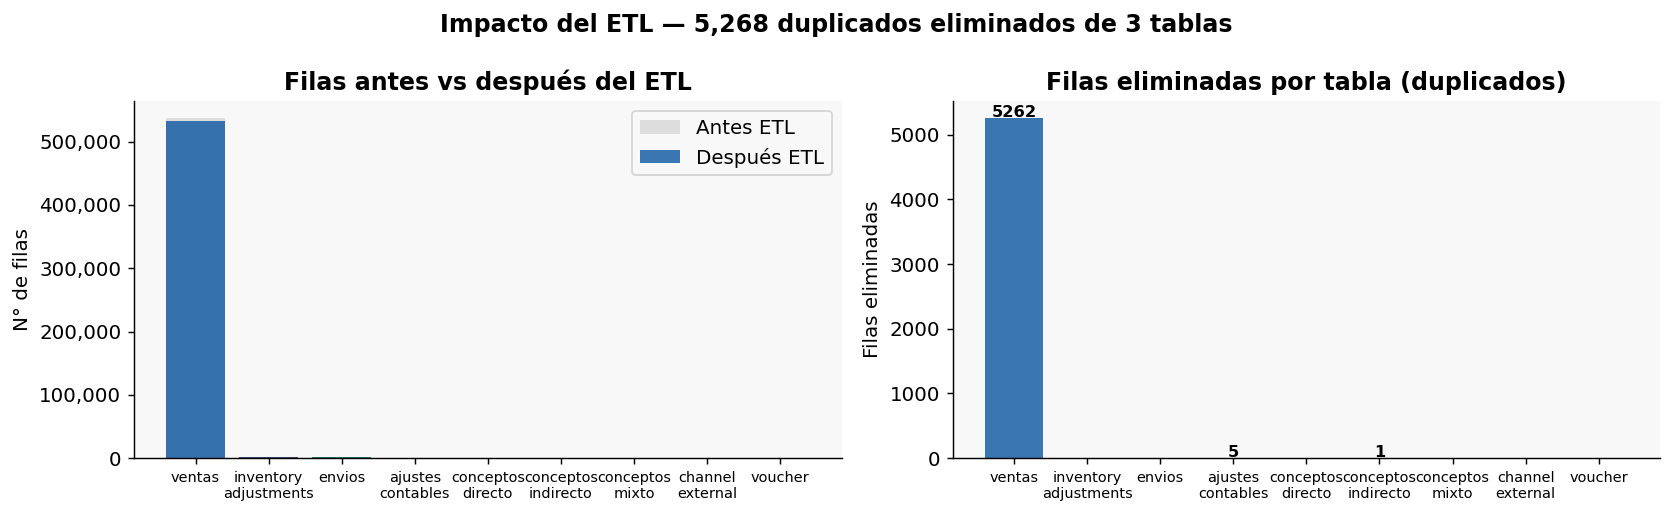

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

nombres_cortos = [t.replace('dim_','').replace('_','\n') for t in TABLAS]
filas_antes_v  = [snapshot_inicial[t]['filas'] for t in TABLAS]
filas_desp_v   = [len(tablas[t]) for t in TABLAS]
eliminadas_v   = [a-d for a,d in zip(filas_antes_v, filas_desp_v)]

colores = ['#185FA5','#1D3461','#0F6E56','#854F0B','#993556',
           '#444444','#C56F1A','#A32D2D','#534AB7']

x = range(len(TABLAS))
axes[0].bar(x, filas_antes_v, color='#ccc', edgecolor='none', label='Antes ETL', alpha=0.6)
axes[0].bar(x, filas_desp_v, color=colores, edgecolor='none', label='Después ETL', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(nombres_cortos, fontsize=8)
axes[0].set_title('Filas antes vs después del ETL', fontweight='bold')
axes[0].set_ylabel('N° de filas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[0].legend()

axes[1].bar(x, eliminadas_v, color=[c if e>0 else '#eee' for c,e in zip(colores,eliminadas_v)],
            edgecolor='none', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(nombres_cortos, fontsize=8)
axes[1].set_title('Filas eliminadas por tabla (duplicados)', fontweight='bold')
axes[1].set_ylabel('Filas eliminadas')
for bar, val in zip(axes[1].patches, eliminadas_v):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                     str(val), ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Impacto del ETL — {sum(eliminadas_v):,} duplicados eliminados de {sum(1 for e in eliminadas_v if e > 0)} tablas', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/03_impacto_etl.png', dpi=130, bbox_inches='tight')
plt.show()

**Verificación completada.** El dataset limpio tiene 536.641 filas — exactamente 5.268 menos que el original (los duplicados exactos). Los SC únicos se redujeron en `dim_ventas` por la normalización de sufijos en minúscula. Nulos residuales solo en CustomerID donde es comportamiento de diseño.

---
## 9. Exportación — CSVs + Excel <a id='9'></a>

Se exporta en dos formatos:
- **9 CSVs individuales** en `data/clean/` — para el pipeline SQL/Python posterior
- **1 Excel** `ecommerce_uk_clean.xlsx` con 10 hojas (9 tablas + 1 resumen) — para análisis en herramientas BI

Ambos formatos contienen exactamente el mismo dato. Se verifica que las dimensiones del archivo exportado coinciden con el DataFrame en memoria.

In [14]:
log_export = []

for nombre, sub in tablas.items():
    ruta_csv = f'{CSV_DIR}{nombre}.csv'
    sub.to_csv(ruta_csv, index=False, encoding='utf-8-sig')

    check = pd.read_csv(ruta_csv, encoding='utf-8-sig')
    ok    = check.shape == sub.shape

    log_export.append({
        'Tabla':       nombre,
        'Filas':       sub.shape[0],
        'Columnas':    sub.shape[1],
        'CSV shape':   f'{check.shape[0]} × {check.shape[1]}',
        'Verificación':f'{"OK ✓" if ok else "ERROR ✗"}',
        'Ruta':        ruta_csv,
    })

pd.DataFrame(log_export)[['Tabla','Filas','Columnas','CSV shape','Verificación']]

,Tabla,Filas,Columnas,CSV shape,Verificación
0,dim_ventas,532328,15,532328 × 15,OK ✓
1,inventory_adjustments,1324,9,1324 × 9,OK ✓
2,dim_envios,2110,9,2110 × 9,OK ✓
3,dim_ajustes_contables,570,10,570 × 10,OK ✓
4,dim_conceptos_directo,97,9,97 × 9,OK ✓
5,dim_conceptos_indirecto,96,9,96 × 9,OK ✓
6,dim_conceptos_mixto,37,9,37 × 9,OK ✓
7,dim_channel_external,45,9,45 × 9,OK ✓
8,dim_voucher,34,9,34 × 9,OK ✓


In [15]:
decisiones_etl = pd.DataFrame([
    {
        'ID':    'ETL-01',
        'Paso':  'Tipos de datos',
        'Transformación': 'CustomerID float64 → Int64',
        'Tablas afectadas': 'Todas (9)',
        'Filas afectadas': 'Todos los registros con CID',
        'Justificación': 'CustomerID es un identificador entero — float64 es incorrecto semánticamente y causa errores en joins',
        'Alternativas descartadas': 'Mantener float64 (produce decimales en exports), convertir a string (pierde operabilidad numérica)',
        'Impacto análisis': 'Joins y agrupaciones correctas en SQL/Python posterior',
    },
    {
        'ID':    'ETL-02',
        'Paso':  'Estandarización texto',
        'Transformación': 'StockCode .strip().upper() — normalizar sufijos minúscula',
        'Tablas afectadas': 'dim_ventas (1.942 filas)',
        'Filas afectadas': '1.942',
        'Justificación': 'StockCodes con sufijo en minúscula (85049a) son el mismo producto que 85049A — error tipográfico del sistema de origen',
        'Alternativas descartadas': 'Mantener minúscula (duplicaría el catálogo de productos), eliminar filas (pérdida de datos válidos)',
        'Impacto análisis': 'Catálogo de productos coherente — mismo SC agrupa todas sus ventas',
    },
    {
        'ID':    'ETL-03',
        'Paso':  'Estandarización texto',
        'Transformación': 'Description .strip() + normalizar espacios',
        'Tablas afectadas': 'Todas',
        'Filas afectadas': '32 (símbolo £ non-ASCII en dim_voucher)',
        'Justificación': 'Caracteres non-ASCII en vouchers con símbolo £ — problema de encoding del sistema de origen',
        'Alternativas descartadas': 'Eliminar filas (pérdida de datos de vouchers), ignorar (caracteres corruptos en exports)',
        'Impacto análisis': 'Description exporta correctamente en CSV y Excel',
    },
    {
        'ID':    'ETL-04',
        'Paso':  'Deduplicación',
        'Transformación': 'drop_duplicates(keep="first") — duplicados exactos',
        'Tablas afectadas': 'dim_ventas, dim_ajustes_contables, dim_conceptos_indirecto',
        'Filas afectadas': '5.268',
        'Justificación': 'Duplicados exactos en todas las columnas — mismo registro cargado más de una vez en el sistema de origen',
        'Alternativas descartadas': 'keep="last" (resultado idéntico — todas las copias son iguales), no deduplicar (infla revenue y KPIs)',
        'Impacto análisis': 'Revenue y conteos correctos — sin inflación por registros repetidos',
    },
    {
        'ID':    'ETL-05',
        'Paso':  'Nulos',
        'Transformación': 'CustomerID nulo en dim_ventas → mantener NA + flag IsGuest',
        'Tablas afectadas': 'dim_ventas',
        'Filas afectadas': '132.681',
        'Justificación': 'Son ventas anónimas reales (£1.48M revenue) — no errores de carga. Imputar un ID ficticio distorsionaría el análisis de clientes',
        'Alternativas descartadas': 'Eliminar filas (pérdida de £1.48M revenue), imputar ID ficticio (distorsión del análisis)',
        'Impacto análisis': 'Segmento GUEST identificable vía flag IsGuest — análisis correcto de ventas identificadas vs anónimas',
    },
    {
        'ID':    'ETL-06',
        'Paso':  'Nulos',
        'Transformación': 'Description nulo → imputar valor centinela por tabla',
        'Tablas afectadas': 'dim_ventas, inventory_adjustments, dim_channel_external, dim_voucher',
        'Filas afectadas': '1.448',
        'Justificación': 'Sin información disponible — valor centinela legible mejor que NA para exports y dashboards',
        'Alternativas descartadas': 'Mantener NA (genera errores en concatenaciones de texto), imputar moda (asignaría nombre incorrecto)',
        'Impacto análisis': 'Sin valores nulos en Description — dashboards y reportes sin errores de visualización',
    },
    {
        'ID':    'ETL-07',
        'Paso':  'Outliers',
        'Transformación': 'UnitPrice negativo → mantener + flag is_negative_price',
        'Tablas afectadas': 'dim_ajustes_contables',
        'Filas afectadas': '2',
        'Justificación': 'Asientos A563186/A563187 de bad debt — forman un asiento balanceado de neto £0 con A563185. Son contablemente válidos',
        'Alternativas descartadas': 'Eliminar (rompe el balance contable), convertir a positivo (pierde la dirección del asiento)',
        'Impacto análisis': 'Flag is_negative_price permite excluirlos o incluirlos según el contexto del análisis',
    },
    {
        'ID':    'ETL-08',
        'Paso':  'Outliers',
        'Transformación': 'Quantity extrema (±80.995) → mantener sin modificación',
        'Tablas afectadas': 'dim_ventas',
        'Filas afectadas': '2',
        'Justificación': 'Par venta/cancelación de mayorista (InvoiceNo 541431 / C541433) — completamente legítimo. Ningún error de carga',
        'Alternativas descartadas': 'Winsorizar (distorsionaría el revenue de un cliente real), eliminar (pérdida de datos válidos)',
        'Impacto análisis': 'Revenue de mayoristas internacionales representado correctamente',
    },
    {
        'ID':    'ETL-09',
        'Paso':  'Columnas calculadas',
        'Transformación': 'Revenue = Quantity × UnitPrice',
        'Tablas afectadas': 'Todas (9)',
        'Filas afectadas': 'Todos los registros',
        'Justificación': 'Métrica principal del análisis — derivable exactamente del dato original, sin pérdida de información',
        'Alternativas descartadas': 'Calcular solo en SQL (duplica la lógica), no calcular (obliga a recalcular en cada análisis)',
        'Impacto análisis': 'Revenue disponible directamente en el dataset — análisis más eficiente',
    },
    {
        'ID':    'ETL-10',
        'Paso':  'Columnas calculadas',
        'Transformación': 'IsCancellation, Year, Month, DayOfWeek, Hour, IsGuest',
        'Tablas afectadas': 'dim_ventas',
        'Filas afectadas': 'Todos los registros de dim_ventas',
        'Justificación': 'Columnas frecuentemente usadas en análisis temporal y de segmentación — evita recalcular en cada consulta',
        'Alternativas descartadas': 'Calcular solo en SQL (duplica lógica), no calcular (menos eficiente)',
        'Impacto análisis': 'Análisis temporal y de segmentación directamente disponibles',
    },
])

with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:

    # Hoja de resumen — primera hoja
    resumen_excel = pd.DataFrame([{
        'Tabla':    nombre,
        'Filas':    len(sub),
        'Columnas': sub.shape[1],
        'SC únicos':sub['StockCode'].nunique(),
        'Revenue':  round(sub['Revenue'].sum(), 2),
        'Nulos CID':sub['CustomerID'].isna().sum(),
    } for nombre, sub in tablas.items()])

    resumen_excel.to_excel(writer, sheet_name='_resumen', index=False)

    # 9 hojas de datos
    for nombre, sub in tablas.items():
        # Nombre de hoja truncado a 31 chars (límite Excel)
        sheet_name = nombre[:31]
        sub.to_excel(writer, sheet_name=sheet_name, index=False)

    # Hoja de decisiones ETL — incluida aqui para evitar mode='a'
    decisiones_etl.to_excel(writer, sheet_name='_decisiones_etl', index=False)

print(f'Excel exportado: {EXCEL_PATH}')
print(f'Hojas: 11 (9 tablas + 1 resumen + 1 decisiones ETL)')

# Verificar Excel
import openpyxl
wb = openpyxl.load_workbook(EXCEL_PATH)
for sheet in wb.sheetnames:
    ws = wb[sheet]
    print(f'  {sheet:<35} {ws.max_row-1:>6,} filas · {ws.max_column} columnas')

Excel exportado: ../data/clean/ecommerce_uk_clean.xlsx
Hojas: 11 (9 tablas + 1 resumen + 1 decisiones ETL)
  _resumen                                 9 filas · 6 columnas
  dim_ventas                          532,328 filas · 15 columnas
  inventory_adjustments                1,324 filas · 9 columnas
  dim_envios                           2,110 filas · 9 columnas
  dim_ajustes_contables                  570 filas · 10 columnas
  dim_conceptos_directo                   97 filas · 9 columnas
  dim_conceptos_indirecto                 96 filas · 9 columnas
  dim_conceptos_mixto                     37 filas · 9 columnas
  dim_channel_external                    45 filas · 9 columnas
  dim_voucher                             34 filas · 9 columnas
  _decisiones_etl                         10 filas · 8 columnas


**Exportación completada.** Los 9 CSVs y el Excel están en `data/clean/`. Cada CSV fue verificado leyéndolo nuevamente y comparando dimensiones con el DataFrame en memoria.

---
## 10. Documentación de decisiones ETL <a id='10'></a>

Registro completo de todas las transformaciones aplicadas: qué se hizo, por qué, qué alternativas se descartaron y qué impacto tiene sobre el análisis posterior.

In [16]:
decisiones_etl[['ID','Paso','Transformación','Filas afectadas','Justificación']]

,ID,Paso,Transformación,Filas afectadas,Justificación
0,ETL-01,Tipos de datos,CustomerID float64 → Int64,Todos los registros con CID,CustomerID es un identificador entero — float6...
1,ETL-02,Estandarización texto,StockCode .strip().upper() — normalizar sufijo...,1.942,StockCodes con sufijo en minúscula (85049a) so...
2,ETL-03,Estandarización texto,Description .strip() + normalizar espacios,32 (símbolo £ non-ASCII en dim_voucher),Caracteres non-ASCII en vouchers con símbolo £...
3,ETL-04,Deduplicación,"drop_duplicates(keep=""first"") — duplicados exa...",5.268,Duplicados exactos en todas las columnas — mis...
4,ETL-05,Nulos,CustomerID nulo en dim_ventas → mantener NA + ...,132.681,Son ventas anónimas reales (£1.48M revenue) — ...
5,ETL-06,Nulos,Description nulo → imputar valor centinela por...,1.448,Sin información disponible — valor centinela l...
6,ETL-07,Outliers,UnitPrice negativo → mantener + flag is_negati...,2,Asientos A563186/A563187 de bad debt — forman ...
7,ETL-08,Outliers,Quantity extrema (±80.995) → mantener sin modi...,2,Par venta/cancelación de mayorista (InvoiceNo ...
8,ETL-09,Columnas calculadas,Revenue = Quantity × UnitPrice,Todos los registros,Métrica principal del análisis — derivable exa...
9,ETL-10,Columnas calculadas,"IsCancellation, Year, Month, DayOfWeek, Hour, ...",Todos los registros de dim_ventas,Columnas frecuentemente usadas en análisis tem...


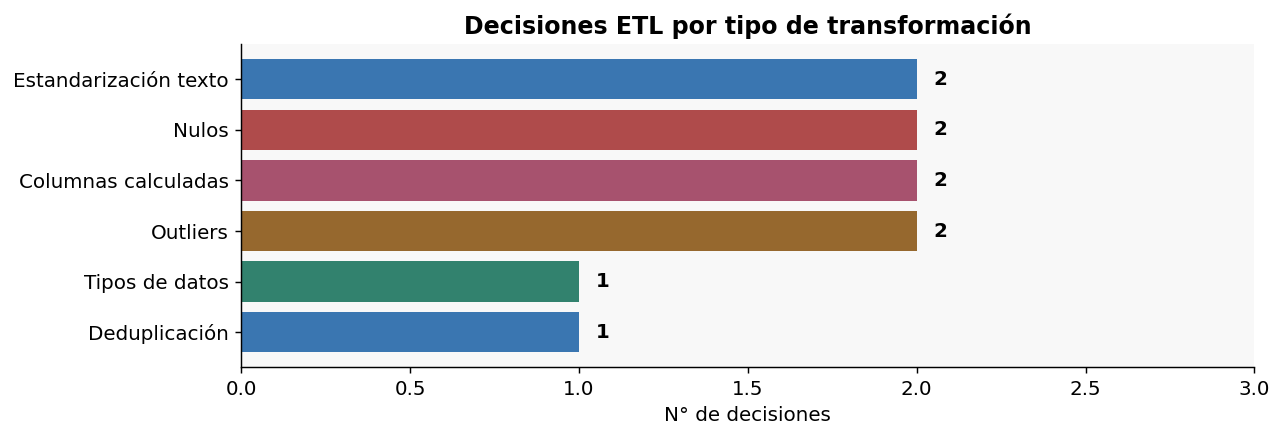

  Dataset original:   541,909 filas
  Dataset limpio:     536,641 filas
  Filas eliminadas:   5,268 (duplicados exactos)
  Transformaciones:   10 decisiones documentadas
  Archivos generados: 9 CSVs + 1 Excel (11 hojas)


In [17]:
fig, ax = plt.subplots(figsize=(10, 3.5))

pasos_count = decisiones_etl['Paso'].value_counts()
colores_log = ['#185FA5','#0F6E56','#854F0B','#993556','#A32D2D']
bars = ax.barh(pasos_count.index[::-1], pasos_count.values[::-1],
               color=colores_log[:len(pasos_count)], edgecolor='none', alpha=0.85)
for bar, val in zip(bars, pasos_count.values[::-1]):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')
ax.set_title('Decisiones ETL por tipo de transformación', fontweight='bold')
ax.set_xlabel('N° de decisiones')
ax.set_xlim(0, pasos_count.max() + 1)
plt.tight_layout()
plt.savefig('../assets/03_decisiones_etl.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'  Dataset original:   {total_antes:,} filas')
print(f'  Dataset limpio:     {sum(len(t) for t in tablas.values()):,} filas')
print(f'  Filas eliminadas:   {total_elim:,} (duplicados exactos)')
print(f'  Transformaciones:   {len(decisiones_etl)} decisiones documentadas')
print(f'  Archivos generados: 9 CSVs + 1 Excel (11 hojas)')